
# **기상 데이터 및 선형회귀분석을 사용한 태양광 발전량 예측 모델**
# **(Prediction Model of Solar Power Generation Using Meteorological Data and Linear Regression Analysis)**



### **2. 데이터 특성분석**

---
---

(1) 기술통계


[학습 목표]

* pandas, matplotlib.pyplot 라이브러리를 사용한 기술통계량 및 그래프 출력 방법 학습


[사용데이터 및 변수 설명]

- training_set.csv : 아래 변수를 1시간 간격으로 총 119시간 수집한 데이터, 분석 및 모델 구축에 사용
- test_set.csv :  아래 변수를 1시간 간격으로 총 30시간 수집한 데이터,  모델 성능평가에 사용


-  'power'    : 'Power generation (kWh)', 발전량
-  'temp_air' : 'Temperature (°C)' , 기온
-  'temp_gnd' : 'Ground surface temperature (°C)', 지면온도
-  'humi'     : 'Relative humidity (%)', 상대습도
-  'insol'    : 'Insolation (MJ/m2)', 일사량


[기술통계량 출력방법]

        # 출력방법
        import pandas as pd
        데이터프레임.describe().round(반올림 자리수).T  

        # 사용예시
        import pandas as pd
        df.describe().round(2).T
        


[그래프 출력방법]
        
        # 출력방법(1)
        import matplotlib.pyplot as plt
        plt.plot(입력값)                              # plot 그림, 입력값으로는 리스트 등 사용  
        plt.show()                                    # plot 출력

        # 출력방법(2) - 축 제목, 눈금 표시값 등 설정
        import matplotlib.pyplot as plt
        plt.figure(figsize=(x축 크기, y축 크기))      # plot 크기 설정
        plt.plot(입력값)                              # plot 그림
        plt.xlabel('x축 제목')                        # x축 제목 설정
        plt.ylabel('y축 제목')                        # y축 제목 설정
        plt.xticks(range(시작 지점, 종료 지점, 간격)) # x축 눈금 표시값 설정
        plt.xlim([시작 지점, 종료 지점])              # x축 표시범위 설정
        plt.show()                                    # plot 출력

        # 사용예시
        import matplotlib.pyplot as plt
        plt_input = df['humi']                        # 입력 데이터
        plt.figure(figsize=(13, 4))                   # plot 크기 설정
        plt.plot(plt_input)                           # plot 그림
        plt.xlabel('Time (h)')                        # x축 제목 설정
        plt.ylabel('Relative humidity (%)')           # y축 제목 설정
        plt.xticks(range(0, len(plt_input), 5))       # x축 눈금 표시값 설정
        plt.xlim([0, len(plt_input)-1])               # x축 표시범위 설정
        plt.show()                                    # plot 출력


---
---

[연습문제 1]

라이브러리(pandas)를 불러온 후, test_set.csv 파일에 저장된 데이터를 불러와 데이터프레임으로 df_tst에 저장하고, df_tst에 저장된 내용을 확인해보시오.

In [41]:
# 풀이
import pandas as pd
df_tst  = pd.read_csv('test_set.csv')
df_tst

,power,temp_air,temp_gnd,humi,insol
0,5.7,14.1,14.3,76,0.36
1,3.5,12.0,13.1,98,0.18
2,0.0,11.0,12.2,100,0.01
3,1.7,10.9,11.6,100,0.00
4,0.8,10.7,11.1,100,0.00
5,5.8,9.9,9.8,95,0.08
6,12.2,10.3,11.6,97,0.39
7,24.8,11.6,15.5,93,1.08
8,32.4,12.4,16.7,87,1.54
9,5.0,14.0,17.1,80,1.65


[자가진단 1]

라이브러리(pandas)를 불러온 후, training_set.csv 파일에 저장된 데이터를 불러와 데이터프레임으로 df에 저장하고, df에 저장된 내용을 확인해보시오.

In [13]:
# 코딩
import pandas as pd
df = pd.read_csv('training_set.csv')
df


,power,temp_air,temp_gnd,humi,insol
0,5.4,4.6,2.6,100,0.10
1,17.4,8.8,6.1,73,0.69
2,37.9,10.5,12.3,65,1.41
3,54.7,12.2,19.8,61,2.06
4,76.5,12.7,26.2,59,2.68
...,...,...,...,...,...
114,18.4,14.9,14.7,73,0.56
115,15.9,14.7,15.3,74,0.64
116,20.4,15.0,17.2,72,0.79
117,16.5,15.2,17.0,67,0.73


[연습문제 2]

연습문제 1에서 생성한 df_tst에 대한 기술통계량(평균, 표준편차, 최소, 최대 등)을 출력하시오.

In [14]:
# 풀이 (1)
df_tst.describe()
#df_tst.describe().T

## 데이터프레임 변수 정보 확인 코드 참고
# df_tst.info()

,power,temp_air,temp_gnd,humi,insol
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,26.660000,10.256667,12.543333,77.100000,1.059333
std,28.774145,1.809493,3.420998,21.011245,1.031517
min,0.000000,6.500000,4.900000,45.000000,0.000000
25%,5.100000,9.425000,10.650000,54.000000,0.245000
50%,17.400000,10.100000,12.300000,83.500000,0.700000
75%,39.225000,11.075000,15.475000,97.000000,1.622500
max,93.500000,14.100000,17.600000,100.000000,3.190000


In [15]:
# 풀이 (2)
print("표. 데이터 특성")
print("Table. Characteristics of data")
print("----------------------------------------------------------")
print(df_tst.describe().T[['count', 'mean', 'std', '50%' ,'min', 'max']])

표. 데이터 특성
Table. Characteristics of data
----------------------------------------------------------
          count       mean        std   50%   min     max
power      30.0  26.660000  28.774145  17.4   0.0   93.50
temp_air   30.0  10.256667   1.809493  10.1   6.5   14.10
temp_gnd   30.0  12.543333   3.420998  12.3   4.9   17.60
humi       30.0  77.100000  21.011245  83.5  45.0  100.00
insol      30.0   1.059333   1.031517   0.7   0.0    3.19


[자가진단 2]

자가진단 1에서 생성한 df에 대한 기술통계량(평균, 표준편차, 최소, 최대 등)을 출력하시오.

In [16]:
# 코딩
df.describe().T


,count,mean,std,min,25%,50%,75%,max
power,119.0,40.393277,27.715910,0.7,16.10,38.10,64.90,90.70
temp_air,119.0,13.926050,3.886514,2.6,11.90,14.30,16.55,23.30
temp_gnd,119.0,20.036134,8.664556,2.6,14.25,20.20,27.70,35.70
humi,119.0,62.025210,20.025603,27.0,45.00,59.00,74.50,100.00
insol,119.0,1.553529,0.983708,0.0,0.69,1.55,2.39,3.39


[연습문제 3]

연습문제 1에서 생성한 df_tst에 대한 기술통계량(평균, 표준편차, 최소, 최대 등)을 소수점 둘째 자리까지 반올림하여 출력하시오.

In [17]:
# 풀이
df_tst.describe().round(2).T
# data_ch = df_tst.describe().round(2)
# data_ch.T

,count,mean,std,min,25%,50%,75%,max
power,30.0,26.66,28.77,0.0,5.10,17.4,39.22,93.50
temp_air,30.0,10.26,1.81,6.5,9.43,10.1,11.08,14.10
temp_gnd,30.0,12.54,3.42,4.9,10.65,12.3,15.48,17.60
humi,30.0,77.10,21.01,45.0,54.00,83.5,97.00,100.00
insol,30.0,1.06,1.03,0.0,0.24,0.7,1.62,3.19


[자가진단 3]

자가진단 1에서 생성한 df에 대한 기술통계량(평균, 표준편차, 최소, 최대 등)을 소수점 둘째 자리까지 반올림하여 출력하시오.

In [18]:
# 코딩
df.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
power,119.0,40.39,27.72,0.7,16.10,38.10,64.90,90.70
temp_air,119.0,13.93,3.89,2.6,11.90,14.30,16.55,23.30
temp_gnd,119.0,20.04,8.66,2.6,14.25,20.20,27.70,35.70
humi,119.0,62.03,20.03,27.0,45.00,59.00,74.50,100.00
insol,119.0,1.55,0.98,0.0,0.69,1.55,2.39,3.39


[연습문제 4]

연습문제 1에서 생성한 df_tst에서 power에 대한 그래프를 출력하시오.

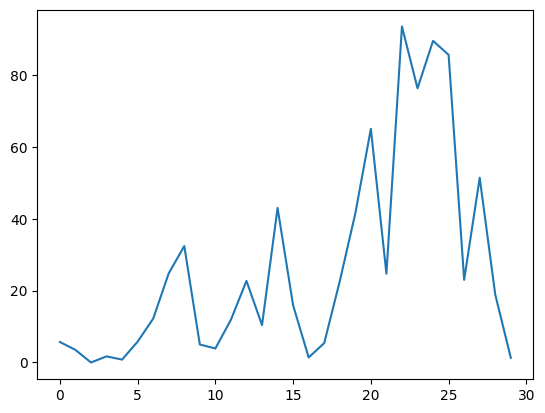

In [19]:
# 풀이 (1)
import matplotlib.pyplot as plt

power = list(df_tst['power']) # list 데이터

plt.plot(power) # plot 그림
plt.show()      # plot 출력

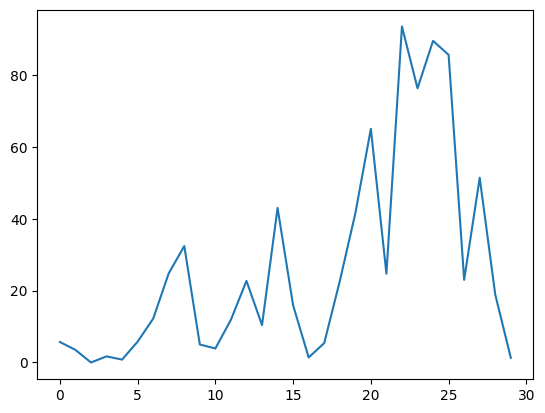

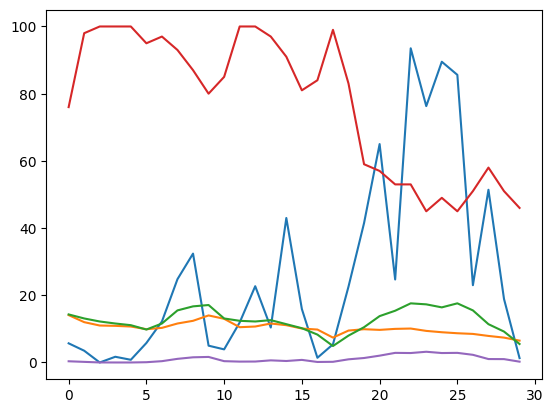

In [20]:
# 풀이 (2)
import matplotlib.pyplot as plt

power = df_tst['power']   # series 데이터

plt.plot(power)
plt.show()

# 데이터프레임 입력 시 출력결과 참고
plt.plot(df_tst)
plt.show()

[자가진단 4]

자가진단 1에서 생성한 df에서 humi에 대한 그래프를 출력하시오.

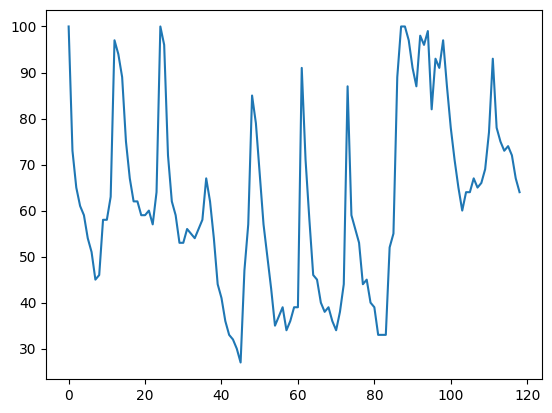

In [21]:
# 코딩
import matplotlib.pyplot as plt

humi = df['humi']

plt.plot(humi)
plt.show()


[연습문제 5]

연습문제 1에서 생성한 df_tst에서 power에 대한 그래프를 (1) 출력되는 그림의 크기를 설정하고, (2) x축 및 y축 제목을 각각 'Time (h)'와 'Power generation (kWh)'로 설정하고, (3) x축 눈금의 표시값과 표시범위를 설정하여 출력하시오.

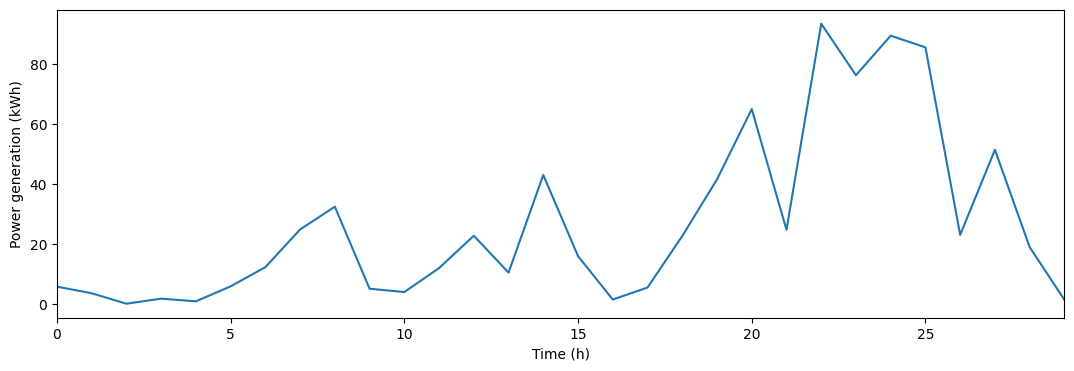

In [43]:
# 풀이
import matplotlib.pyplot as plt
import pandas as pd

df_tst  = pd.read_csv('test_set.csv') # df_tst 정의 추가
plt_input = list(df_tst['power'])             # 입력 데이터

plt.figure(figsize=(13, 4))                   # plot 크기 설정
plt.plot(plt_input)                           # plot 그림

plt.xlabel('Time (h)')                        # x축 제목 설정
plt.ylabel('Power generation (kWh)')          # y축 제목 설정

plt.xticks(range(0, len(plt_input), 5))       # x축 눈금 표시값 설정
plt.xlim([0, len(plt_input)-1])               # x축 표시범위 설정

plt.show()                                    # plot 출력

[자가진단 5]

자가진단 1에서 생성한 df에서 humi에 대한 그래프를 (1) 출력되는 그림의 크기를 설정하고, (2) x축 및 y축 제목을 각각 'Time (h)'와 'Relative humidity (%)'로 설정하고, (3) x축 눈금의 표시값과 표시범위를 설정하여 출력하시오.

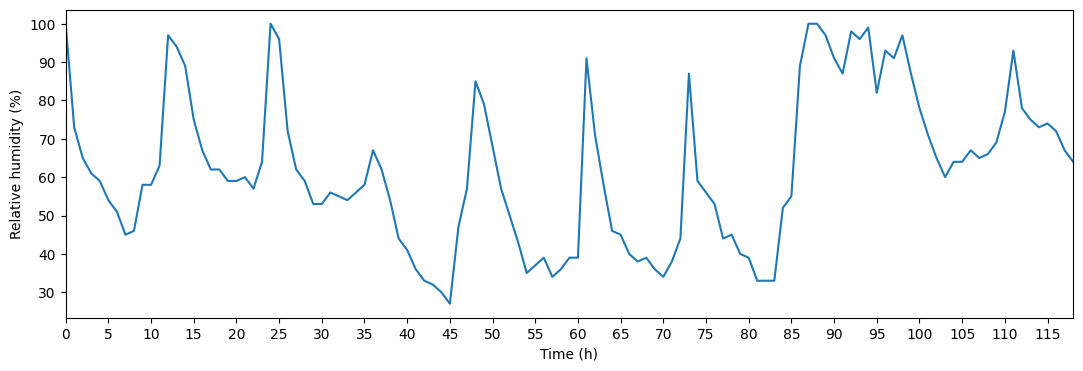

In [74]:
# 코딩
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('training_set.csv') # df 정의 추가
plt_input = list(df['humi'])             # 입력 데이터

plt.figure(figsize=(13, 4))                   # plot 크기 설정
plt.plot(plt_input)                           # plot 그림

plt.xlabel('Time (h)')                        # x축 제목 설정
plt.ylabel('Relative humidity (%)')           # y축 제목 설정

plt.xticks(range(0, len(plt_input), 5))       # x축 눈금 표시값 설정
plt.xlim([0, len(plt_input)-1])               # x축 표시범위 설정

plt.show()                                    # plot 출력

[형성평가 1]

training_set.csv 파일에 저장된 데이터를 데이터프레임으로 df에 저장하고, df에 대한 기술통계량(평균, 표준편차, 최소, 최대 등)을 소수점 둘째 자리까지 반올림하여 출력하시오.

In [47]:
# 코딩
df.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
power,119.0,40.39,27.72,0.7,16.10,38.10,64.90,90.70
temp_air,119.0,13.93,3.89,2.6,11.90,14.30,16.55,23.30
temp_gnd,119.0,20.04,8.66,2.6,14.25,20.20,27.70,35.70
humi,119.0,62.03,20.03,27.0,45.00,59.00,74.50,100.00
insol,119.0,1.55,0.98,0.0,0.69,1.55,2.39,3.39


[형성평가 2]

df의 각 변수에 대한 그래프를 출력하시오.



* y축 제목 설정 시 참고

        'power'    : 'Power generation (kWh)'
        'temp_air' : 'Temperature (°C)'
        'temp_gnd' : 'Ground surface temperature (°C)'
        'humi'     : 'Relative humidity (%)'
        'insol'    : 'Insolation (MJ/m2)'

         ['Power generation (kWh)',
          'Temperature (°C)',
          'Ground surface temperature (°C)',
          'Relative humidity (%)',
          'Insolation (MJ/m2)']


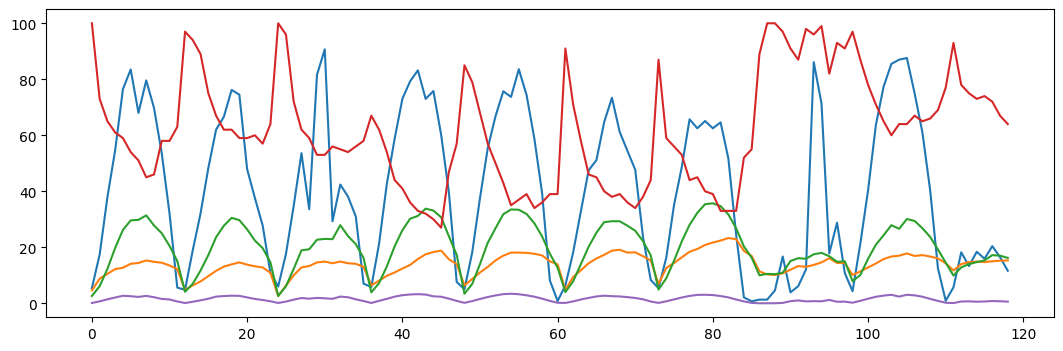

In [54]:
# 코딩
plt.figure(figsize=(13, 4))
plt.plot(df)
plt.show()


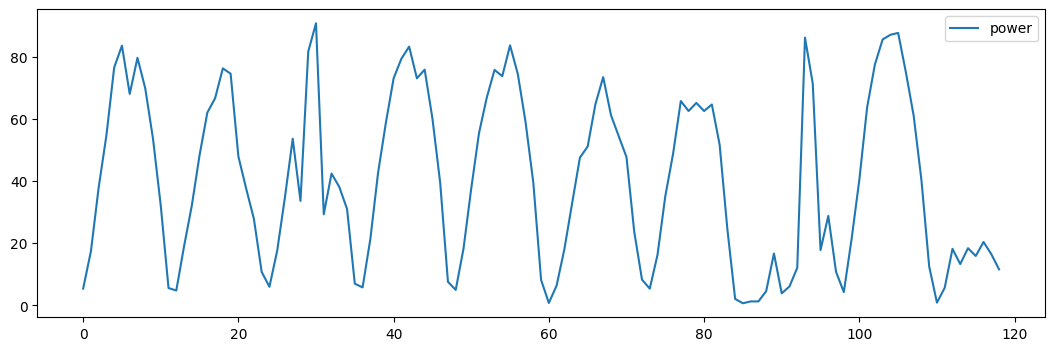

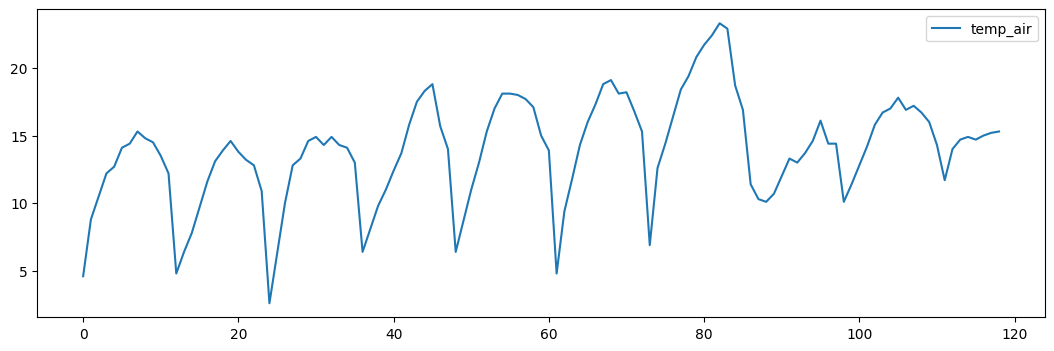

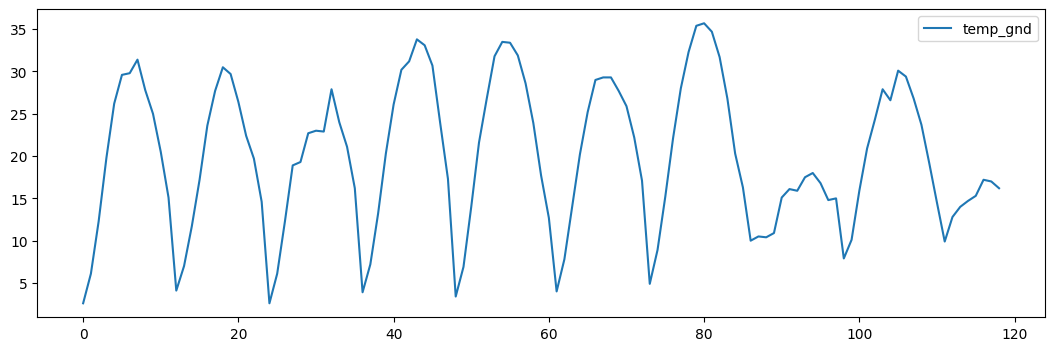

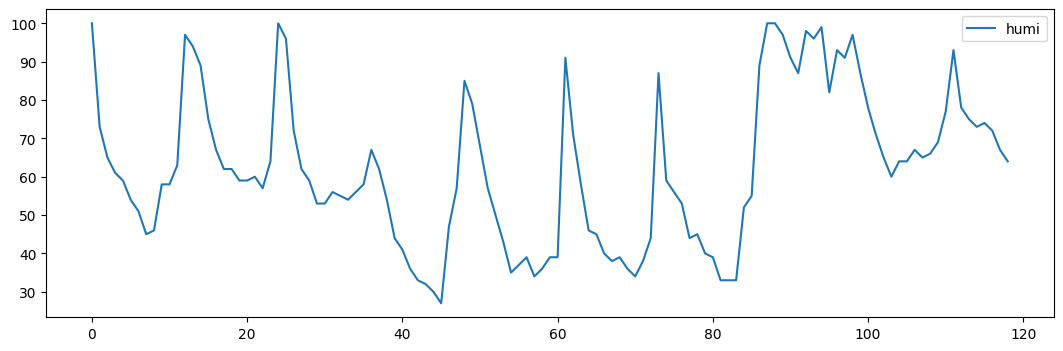

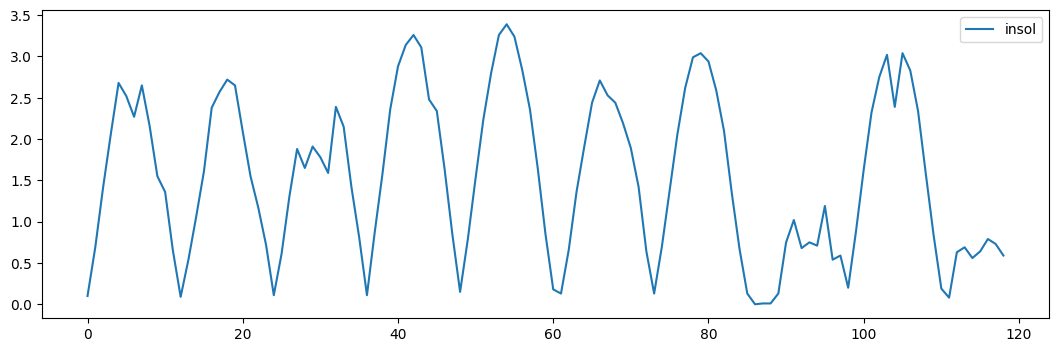

     power  temp_air  temp_gnd  humi  insol
0      5.4       4.6       2.6   100   0.10
1     17.4       8.8       6.1    73   0.69
2     37.9      10.5      12.3    65   1.41
3     54.7      12.2      19.8    61   2.06
4     76.5      12.7      26.2    59   2.68
..     ...       ...       ...   ...    ...
114   18.4      14.9      14.7    73   0.56
115   15.9      14.7      15.3    74   0.64
116   20.4      15.0      17.2    72   0.79
117   16.5      15.2      17.0    67   0.73
118   11.6      15.3      16.2    64   0.59

[119 rows x 5 columns]


In [89]:
for i in df:
    plt_input = list(df[i])

    plt.figure(figsize=(13, 4))
    plt.plot(plt_input)
    plt.legend(labels=[i])

    plt.show()
print(df)

[형성평가 3]

형성평가 1, 2의 코드를 합친 후, 이를 실행시켜보시오.

          count   mean    std   min    25%    50%    75%     max
power     119.0  40.39  27.72   0.7  16.10  38.10  64.90   90.70
temp_air  119.0  13.93   3.89   2.6  11.90  14.30  16.55   23.30
temp_gnd  119.0  20.04   8.66   2.6  14.25  20.20  27.70   35.70
humi      119.0  62.03  20.03  27.0  45.00  59.00  74.50  100.00
insol     119.0   1.55   0.98   0.0   0.69   1.55   2.39    3.39


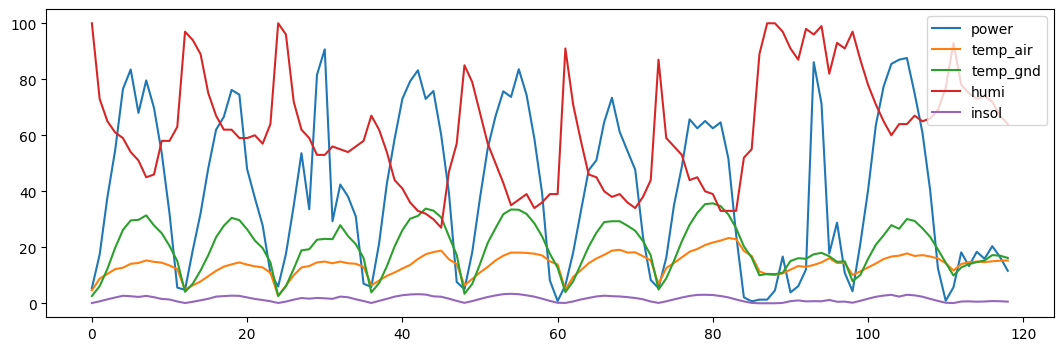

     power  temp_air  temp_gnd  humi  insol
0      5.4       4.6       2.6   100   0.10
1     17.4       8.8       6.1    73   0.69
2     37.9      10.5      12.3    65   1.41
3     54.7      12.2      19.8    61   2.06
4     76.5      12.7      26.2    59   2.68
..     ...       ...       ...   ...    ...
114   18.4      14.9      14.7    73   0.56
115   15.9      14.7      15.3    74   0.64
116   20.4      15.0      17.2    72   0.79
117   16.5      15.2      17.0    67   0.73
118   11.6      15.3      16.2    64   0.59

[119 rows x 5 columns]


In [63]:
# 코딩
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('training_set.csv')

print(df.describe().round(2).T)

plt.figure(figsize=(13, 4))
plt.plot(df)
plt.legend(loc='upper right', labels=df.columns) # Add legend with labels from DataFrame columns
plt.show()
print(df)

---
---

(2) 상관분석


[학습 목표]

* pandas, matplotlib.pyplot, scipy.stats 라이브러리를 사용한 상관계수 및 산점도 출력 방법 학습

[사용데이터 및 변수 설명]

- training_set.csv : 아래 변수를 1시간 간격으로 총 119시간 수집한 데이터, 분석 및 모델 구축에 사용
- test_set.csv :  아래 변수를 1시간 간격으로 총 30시간 수집한 데이터,  모델 성능평가에 사용


-  'power'    : 'Power generation (kWh)', 발전량 (종속변수)
-  'temp_air' : 'Temperature (°C)' , 기온 (독립변수)
-  'temp_gnd' : 'Ground surface temperature (°C)', 지면온도 (독립변수)
-  'humi'     : 'Relative humidity (%)', 상대습도 (독립변수)
-  'insol'    : 'Insolation (MJ/m2)', 일사량 (독립변수)

[scipy.stats 라이브러리]

*  T-검정, 상관분석 등을 제공하는 통계 관련 라이브러리

        # scipy.stats 불러오기
        import scipy.stats as ss

[상관계수 출력방법]

        # 출력방법
        import scipy.stats as ss
        cor =  ss.pearsonr(변수1, 변수2)    # 변수1과 변수2의 피어슨 상관분석 수행
        cor[0]                              # 상관계수 r값 출력
        cor[1]                              # 유의확률 p값 출력

        # 사용예시
        import scipy.stats as ss
        cor =  ss.pearsonr(df['temp_air'], df['power'])  # 상관분석
        print(f'r = {cor[0]:.3f}')                       # r값 출력
        print(f'p = {cor[1]:.3f}')                       # p값 출력

[산점도 출력방법]

        # 출력방법
        import matplotlib.pyplot as plt
        plt.scatter(변수1, 변수2)                        # 산점도 그림
        plt.show()                                       # 산점도 출력

        # 사용예시
        import matplotlib.pyplot as plt
        plt.figure(figsize=(4, 4))               # 산점도 크기 설정
        plt.scatter(df['temp_air'], df['power']) # 산점도 그림
        plt.xlabel('temp_air')                   # x축 제목 설정
        plt.ylabel('power')                      # y축 제목 설정
        plt.show()




---
---

[연습문제 1]

test_set.csv 파일에 저장된 데이터를 불러와 데이터프레임으로 df_tst에 저장하시오.

In [27]:
# 풀이
import pandas as pd
df_tst = pd.read_csv('test_set.csv')

[자가진단 1]

training_set.csv 파일에 저장된 데이터를 불러와 데이터프레임으로 df에 저장하시오.

In [75]:
# 코딩
import pandas as pd
df = pd.read_csv('training_set.csv')


[연습문제 2]

scipy.stats 라이브러리를 불러온 후, df_tst의 temp_air와 power에 대한 피어슨 상관분석 결과를 출력하시오.

In [29]:
# 풀이
import scipy.stats as ss

x = 'temp_air'
y = 'power'

cor =  ss.pearsonr(df_tst[x], df_tst[y]) # 피어슨 상관분석
print(f'r = {cor[0]:.3f}')
print(f'p = {cor[1]:.3f}')  # 상관성을 보여줌

r = -0.275
p = 0.141


[자가진단 2]

scipy.stats 라이브러리를 불러온 후, df의 temp_air와 power에 대한 피어슨 상관분석 결과를 출력하시오.

In [90]:
# 코딩
import scipy.stats as ss

x = 'temp_air'
y = 'power'

cor = ss.pearsonr(df[x], df[y])
print(f'r = {cor[0]:.3f}')
print(f'p = {cor[1]:.9f}')


r = 0.494
p = 0.000000011


[연습문제 3]

matplotlib.pyplot 라이브러리를 불러온 후, df_tst의 temp_air와 power에 대한 산점도를 출력하시오.

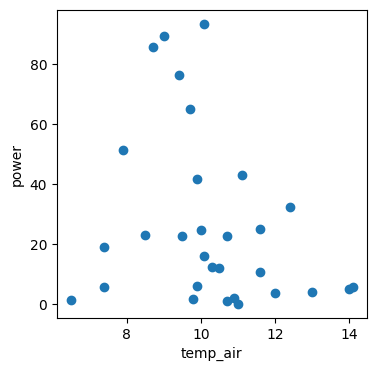

In [31]:
# 풀이
import matplotlib.pyplot as plt

x = 'temp_air'
y = 'power'

plt.figure(figsize=(4, 4))
plt.scatter(df_tst[x], df_tst[y])  # 산점도 그림
plt.xlabel(x)
plt.ylabel(y)
plt.show()

[자가진단 3]

matplotlib.pyplot 라이브러리를 불러온 후, df의 temp_air와 power에 대한 산점도를 출력하시오.

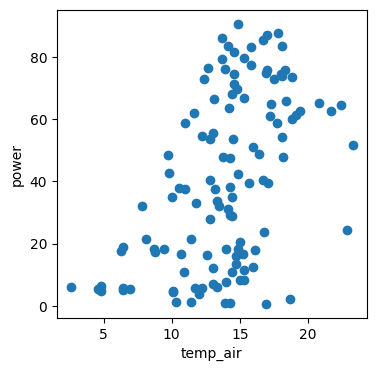

In [78]:
# 코딩
import matplotlib.pyplot as plt

x = 'temp_air'
y = 'power'

plt.figure(figsize=(4, 4))
plt.scatter(df[x], df[y])  # 산점도 그림
plt.xlabel(x)
plt.ylabel(y)
plt.show()

[연습문제 4]

df의 모든 변수에 대한 상관분석 결과와, 히트맵, 산점도를 각각 출력하시오.

          power  temp_air  temp_gnd   humi  insol
power     1.000     0.494     0.802 -0.534  0.898
temp_air  0.494     1.000     0.833 -0.702  0.600
temp_gnd  0.802     0.833     1.000 -0.764  0.896
humi     -0.534    -0.702    -0.764  1.000 -0.704
insol     0.898     0.600     0.896 -0.704  1.000
Axes(0.125,0.11;0.62x0.77)


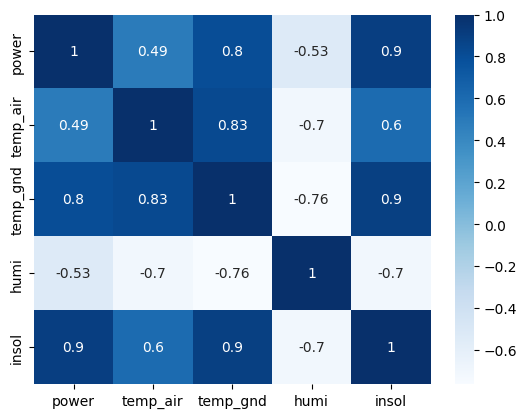

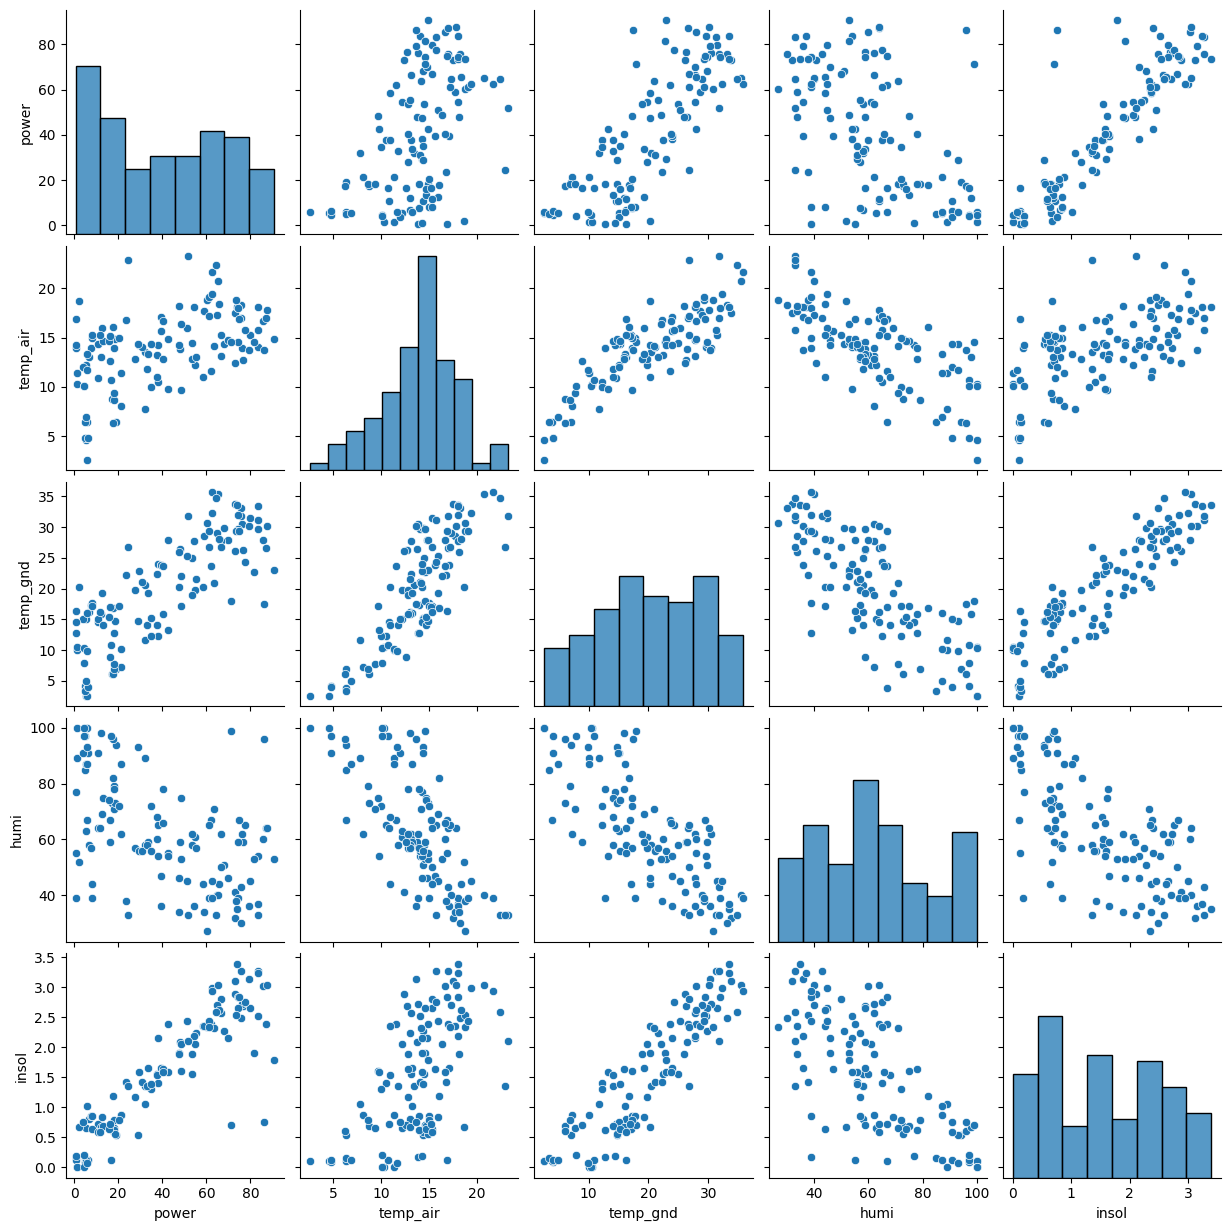

In [33]:
# 풀이
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                        # <-- 라이브러리 추가

df  = pd.read_csv('training_set.csv')
print(df.corr().round(3))                                    # 상관분석
print(sns.heatmap(df.corr(), cmap=plt.cm.Blues, annot=True)) # 히트맵
print(sns.pairplot(df, diag_kind='hist'))                    # 산점도


[형성평가 1]

training_set.csv 파일에 저장된 데이터를 불러와 데이터프레임으로 df에 저장한 후, df의 독립변수(temp_air, temp_gnd, humi, insol)와 종속변수(power)에 대한 피어슨 상관분석 결과를 각각 출력하시오.

In [100]:
# 코딩
import scipy.stats as ss
import pandas as pd

df = pd.read_csv('training_set.csv') # Ensure df is loaded
x = 'power'
for i in df.columns:
    if i == x:
        continue
    cor = ss.pearsonr(df[x], df[i])
    print(f'{x} and {i}:')
    print(f'r = {cor[0]:.3f}')
    print(f'p = {cor[1]:.9f}')
    print("=============")

power and temp_air:
r = 0.494
p = 0.000000011
power and temp_gnd:
r = 0.802
p = 0.000000000
power and humi:
r = -0.534
p = 0.000000000
power and insol:
r = 0.898
p = 0.000000000



[형성평가 2]

df의 독립변수(temp_air, temp_gnd, humi, insol)와 종속변수(power)에 대한 산점도를 각각 출력하시오.

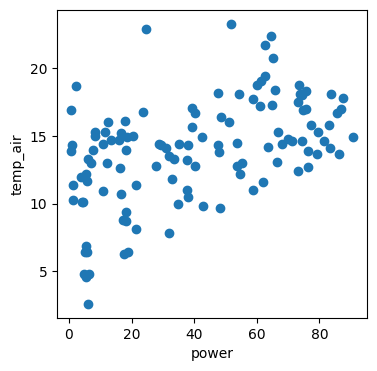

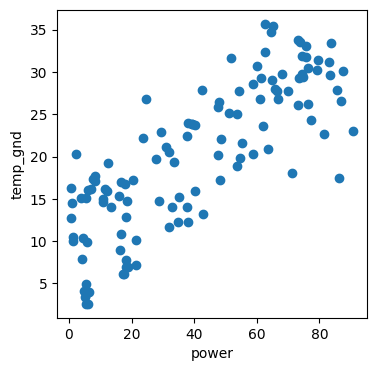

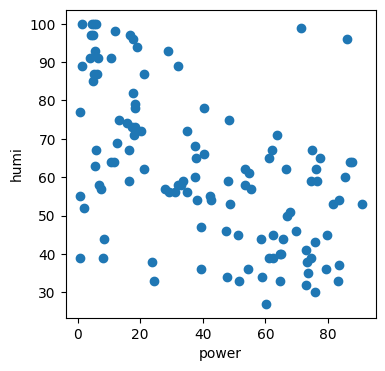

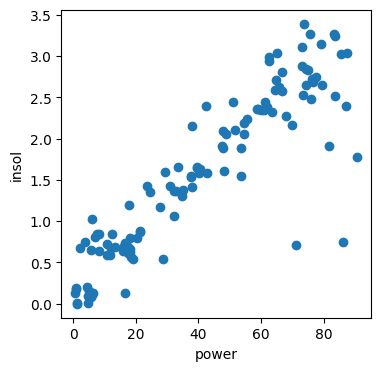

In [102]:
# 코딩
x = 'power'
for i in df.columns:
    if i == x:
        continue
    plt.figure(figsize=(4, 4))
    plt.scatter(df[x], df[i])  # 산점도 그림
    plt.xlabel(x)
    plt.ylabel(i)
    plt.show()


[형성평가 3]

형성평가 1, 2의 코드를 합친 후, 이를 실행시켜보시오.

power and temp_air:
r = 0.494
p = 0.000000011


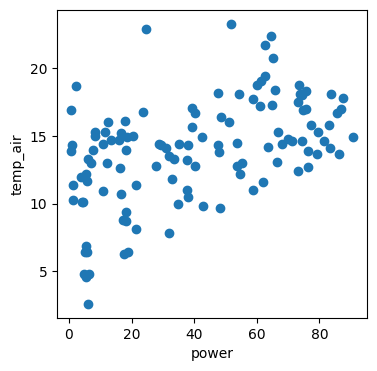

power and temp_gnd:
r = 0.802
p = 0.000000000


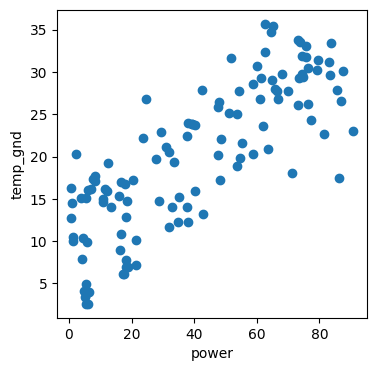

power and humi:
r = -0.534
p = 0.000000000


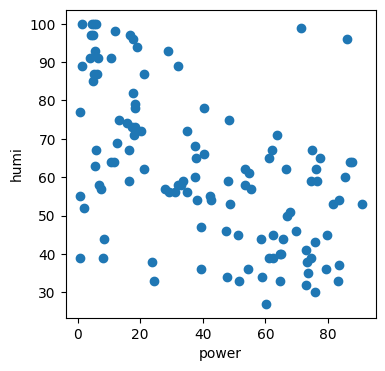

power and insol:
r = 0.898
p = 0.000000000


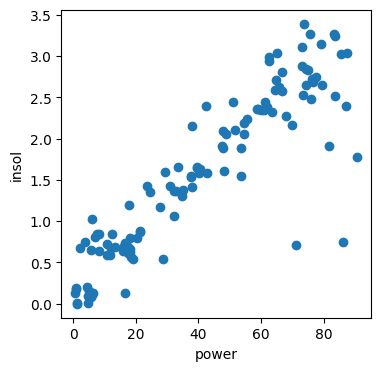

In [103]:
# 코딩
import scipy.stats as ss
import pandas as pd

df = pd.read_csv('training_set.csv') # Ensure df is loaded
x = 'power'
for i in df.columns:
    if i == x:
        continue
    cor = ss.pearsonr(df[x], df[i])
    print(f'{x} and {i}:')
    print(f'r = {cor[0]:.3f}')
    print(f'p = {cor[1]:.9f}')

    plt.figure(figsize=(4, 4))
    plt.scatter(df[x], df[i])  # 산점도 그림
    plt.xlabel(x)
    plt.ylabel(i)
    plt.show()
